<h2> nc_to_asc file</h2>

Convert daily P/PET from a KNMI'23 .nc file (lat/lon grid, ensemble
dimension) into one ESRI ASCII grid per day on the 50 m RD model grid
(nearest-neighbour resampling), and write the accompanying index file.

<h4>Installing the correct python packages</h4>

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pyproj import Transformer

<h4>The functions needed to execute the command to convert the .nc file into .ascii files</h4>

In [3]:
NODATA = -9999

def nearest_index(grid, lat, lon, mask=None):
    """
    For every 50 m model cell, find which climate (lat/lon) grid cell it
    falls into, and return that as two integer index arrays.
 
    Why this is needed: the model grid is defined in RD (meters), but the
    climate data is defined on a much coarser lat/lon grid. To assign a
    precipitation/PET value to each model cell, we first need to know
    which climate cell each model cell physically sits inside.
 
    This is computed once per .nc file
    """
    cs, nr, nc = grid["cellsize"], grid["nrows"], grid["ncols"]
 
    # Cell-center coordinates of every model cell, in RD (meters). Index 0 is the upper-left point of the map
    xc = grid["xll"] + (np.arange(nc) + 0.5) * cs
    yc = grid["yll"] + (nr - np.arange(nr) - 0.5) * cs
    X, Y = np.meshgrid(xc, yc)
 
    # The climate data's coordinates are lat/lon (degrees), so we convert
    # every RD model-cell center to lat/lon to make them comparable.
    tr = Transformer.from_crs(grid["epsg"], 4326, always_xy=True)
    lon_t, lat_t = tr.transform(X.ravel(), Y.ravel())
 
    # For every model cell, find the index of the closest lat value and
    # the closest lon value in the .nc file's coordinate arrays.
    lat_idx = np.abs(lat[None, :] - lat_t[:, None]).argmin(axis=1)
    lon_idx = np.abs(lon[None, :] - lon_t[:, None]).argmin(axis=1)
   
    return lat_idx, lon_idx


def write_asc(path, arr, grid):
    """ Write one 2D array as an ESRI ASCII grid file (.asc)."""
    arr = np.where(np.isnan(arr), NODATA, arr)
    header = (f"ncols {grid['ncols']}\nnrows {grid['nrows']}\n"
              f"xllcorner {grid['xll']}\nyllcorner {grid['yll']}\n"
              f"cellsize {grid['cellsize']}\nNODATA_value {NODATA}")
    np.savetxt(path, arr, header=header, comments="", fmt="%.4f")
 
 
def convert(nc_path, var, ens, prefix, area, out_dir, grid,
            factor=1.0, n_days=None):
    """
    Convert one variable (P or PET) from one .nc file into one .asc file
    per day
    """
    ds = xr.open_dataset(nc_path)
    lat, lon = ds["lat"].values, ds["lon"].values
 
    # Compute the model-cell -> climate-cell mapping once, up front.
    lat_idx, lon_idx = nearest_index(
        grid, lat, lon, ds["mask"] if "mask" in ds else None)
 
    # Select the chosen ensemble member and pull the full time series
    # into memory as a plain numpy array of shape (time, lat, lon).
    data = (ds[var].sel(ens=ens) * factor).transpose("time", "lat", "lon").values
    dates = ds["time"].dt.strftime("%Y%m%d").values
 
    # n_days lets you run a small test batch 
    if n_days:
        data, dates = data[:n_days], dates[:n_days]
 
    folder = os.path.join(out_dir, prefix, area)
    os.makedirs(folder, exist_ok=True)
 
    shape = (grid["nrows"], grid["ncols"])
    for t, d in enumerate(dates):
        # This is the actual resampling step: for day t, look up the
        # climate value at (lat_idx[i], lon_idx[i]) for every model cell
        # i, and reshape the flat result back into the model grid shape.
        arr = data[t][lat_idx, lon_idx].reshape(shape)
        write_asc(os.path.join(folder, f"{prefix}_{d}_{area}.asc"), arr, grid)
 
    print(f"{prefix}: {len(dates)} dagen -> {folder}")
    return list(dates)
 
 
def write_index(dates, modelrun, index_path, rel_root=r"..\..\In\CAP"):
    """
    Write the MetaSWAP-style index file: one line per day with a
    zero-based running index, the calendar year, and relative Windows
    paths to that day's P and PET .asc files.
    """
    with open(index_path, "w") as f:
        for i, d in enumerate(dates):
            p = f'{rel_root}\\P\\{modelrun}\\P_{d}_{modelrun}.asc'
            pet = f'{rel_root}\\PET\\{modelrun}\\PET_{d}_{modelrun}.asc'
            f.write(f'{i:.2f},{d[:4]},"{p}","{pet}"\n')

<h4> The input that needs to be adjusted to your preferences and needs </h4>

In [5]:
P_FILE   = "../Statistical_analyses/pr_ref_interp.nc" # the .nc file of the precipitation needed for the conversion
PET_FILE = "../Statistical_analyses/pet_ref_interp.nc" # the .nc file of the PET needed for the conversion 
P_VAR    = "pr" 
PET_VAR  = "pet"                              
ENS      = 1 # the chosen ensemble member from the bunch 
MODELRUN = "NBr117" # this needs to be adjusted according to the modelrun number that is going to be used
OUT_DIR  = "CAP"
INDEX    = "mete_grid.inp" 
N_DAYS   = None # a few days as a test, otherwise None for the whole modelling period         

grid = dict(xll=0, yll=300000, ncols=300, nrows=325,
            cellsize=1000, epsg=28992)

<h4>The command to execute the conversion to ascii files</h4>

In [7]:
d_p = convert(P_FILE, P_VAR, ENS, "P", MODELRUN, OUT_DIR, grid, n_days=N_DAYS)
d_pet = convert(PET_FILE, PET_VAR, ENS, "PET", MODELRUN, OUT_DIR, grid, n_days=N_DAYS)
write_index(d_p, MODELRUN, INDEX)

P: 10958 dagen -> CAP/P/NBr117
PET: 10958 dagen -> CAP/PET/NBr117


<h4> Testing the results </h4>

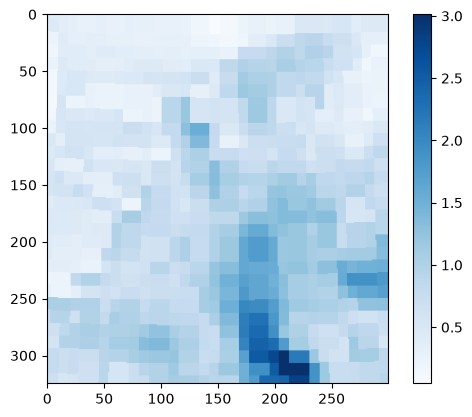

In [17]:
arr = np.loadtxt("CAP/P/NBr117/P_19910101_NBr117.asc", skiprows=6)
plt.imshow(arr, cmap="Blues")
plt.colorbar()

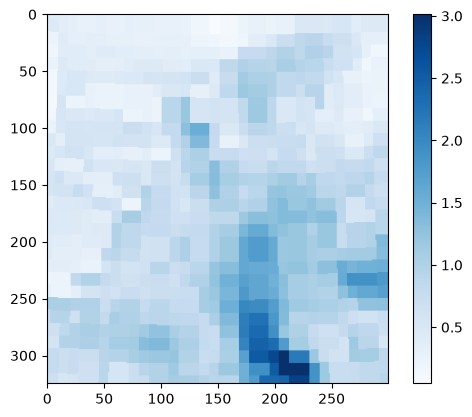

In [19]:
arr2 = np.loadtxt("P_19910101_NBr1.asc", skiprows=6)
plt.imshow(arr, cmap="Blues")
plt.colorbar()